In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

In [46]:
data = fetch_california_housing()

In [47]:
X = data.data
y = data.target

In [48]:
y.shape

(20640,)

In [49]:
df = pd.DataFrame(X, columns = data.feature_names)
df["Target"] = y

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [51]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [52]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20, random_state = 42)

In [53]:
X_train.shape

(16512, 8)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [56]:
lr.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
print(lr.intercept_)
print(lr.coef_)

2.071946937378619
[ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]


In [58]:
y_pred_lr = lr.predict(X_test_scaled)
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.5766495309609692

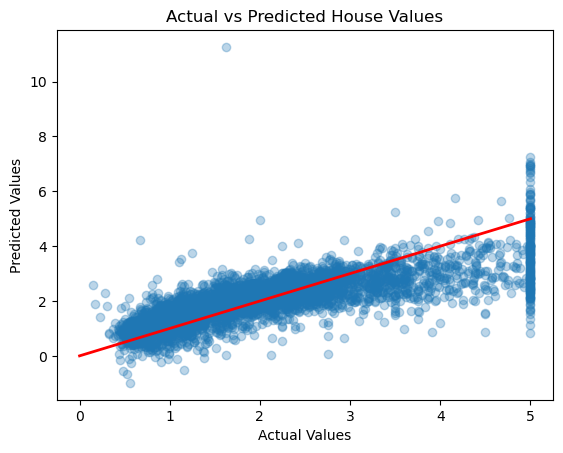

In [59]:
plt.scatter(y_test, y_pred, alpha = 0.3)
# Perfect prediction line
plt.plot([0, 5], [0, 5], color="red", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")

plt.show()


0.5757989317225589
0.5758995026632454
0.5763358440035409
0.5768562568705682
0.5778171692208816
0.5800901498961875
0.5816154300698727
0.5305222464262265
0.4813611325029077


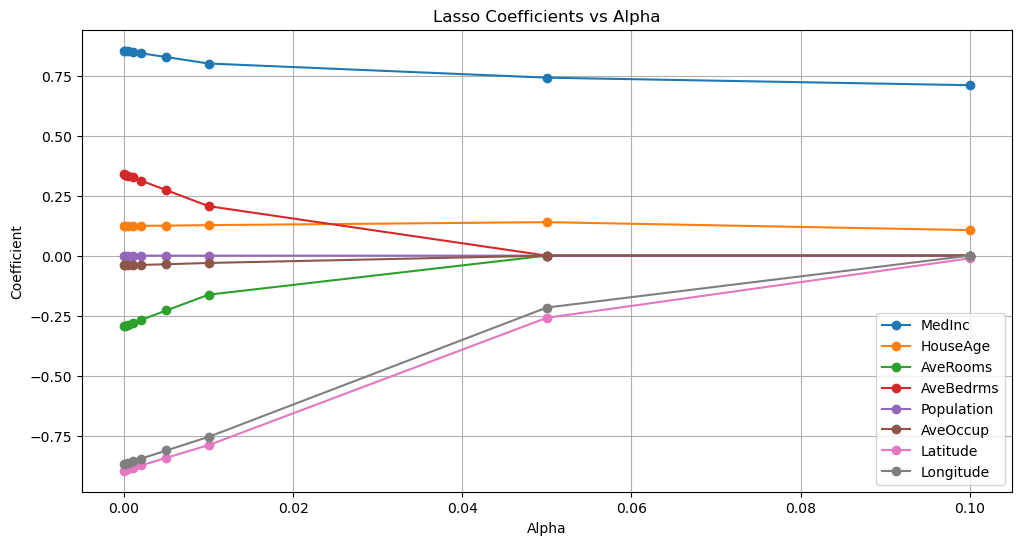

In [60]:
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

alphas = [0.00001, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.05, 0.1]

coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    coefs.append(lasso.coef_)
    print(r2_score(y_test, lasso.predict(X_test_scaled)))

coefs = np.array(coefs)

plt.figure(figsize=(12, 6))

for feature_index in range(X_train_scaled.shape[1]):
    plt.plot(
        alphas,
        coefs[:, feature_index],
        marker='o',
        label=data.feature_names[feature_index]
    )

plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Lasso Coefficients vs Alpha")
plt.legend()
plt.grid()
plt.show()

# automatically find best alpha by lasso CV

In [61]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score

lasso_cv = LassoCV(cv=5, max_iter=10000)

lasso_cv.fit(X_train_scaled, y_train)

print("Best alpha:", lasso_cv.alpha_)

y_pred = lasso_cv.predict(X_test_scaled)

print("R²:", r2_score(y_test, y_pred))

Best alpha: 0.0007985195644260359
R²: 0.5766495309609692


# compare lasso and linear reg

In [62]:
y_pred_lasso = lasso_cv.predict(X_test_scaled)
print("Linear Regression R²:",
      r2_score(y_test, y_pred_lr))

print("Lasso R²:",
      r2_score(y_test, y_pred_lasso))

Linear Regression R²: 0.575787706032451
Lasso R²: 0.5766495309609692


# compare coefficient 

In [63]:
comparison = pd.DataFrame({
    "Feature": data.feature_names,
    "Linear Regression": lr.coef_,
    "Lasso": lasso_cv.coef_
})

comparison

,Feature,Linear Regression,Lasso
0,MedInc,0.854383,0.850206
1,HouseAge,0.122546,0.123187
2,AveRooms,-0.294410,-0.283936
3,AveBedrms,0.339259,0.328723
4,Population,-0.002308,-0.001312
5,AveOccup,-0.040829,-0.040079
6,Latitude,-0.896929,-0.888039
7,Longitude,-0.869842,-0.860441


In [64]:
lasso_cv.alpha_

np.float64(0.0007985195644260359)

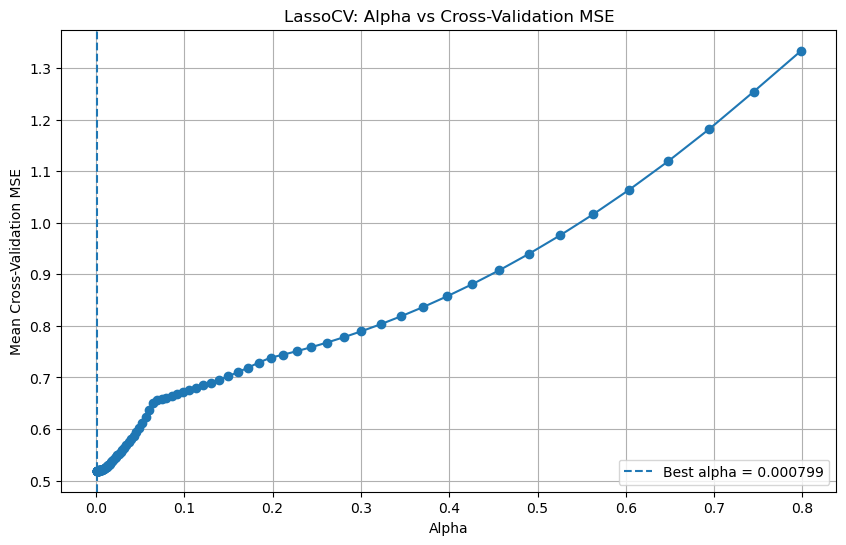

In [68]:
from matplotlib.ticker import ScalarFormatter
alphas = lasso_cv.alphas_
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(alphas, mean_mse, marker='o')

plt.axvline(
    lasso_cv.alpha_,
    linestyle='--',
    label=f'Best alpha = {lasso_cv.alpha_:.6f}'
)

plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.xlabel("Alpha")
plt.ylabel("Mean Cross-Validation MSE")
plt.title("LassoCV: Alpha vs Cross-Validation MSE")
plt.legend()
plt.grid()
plt.show()